<center><h4>CLASSIFICATION ON CIFAR-10 DATASET (COLOUR IMAGES)</h4></center>

#### CIFAR-10 Dataset

- CIFAR-10 contains 60,000 color images of size 32x32 pixels, split into 10 classes. 
- The classes include common objects like airplane, car, bird, cat, deer, dog, frog, horse, ship and truck.
- It has 50,000 training images and 10,000 test images, divided among the 10 classes.

<center><img src='CIFAR.png' border=1 height=600 width=600></center>

### 1. Importing the Basic Libraries

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# It tells Jupyter to display Matplotlib plots directly below the code cell that produced them, inside the notebook.
# You don’t need to call plt.show() 
%matplotlib inline

### 2. Importing the Built-in CIFAR-10 dataset from the Keras

In [56]:
from tensorflow.keras.datasets import cifar10

In [57]:
# Load the CIFAR-10 dataset as Training and Testing data
(X_train,y_train),(X_test,y_test) = cifar10.load_data()

In [58]:
X_train.shape, y_train.shape
# 50,000 Images, each image is 32x32 pixel

((50000, 32, 32, 3), (50000, 1))

In [59]:
# Reading one Image of the CIFAR-10 X_train data
X_train[12]

array([[[164, 215, 244],
        [162, 212, 240],
        [162, 212, 240],
        ...,
        [157, 210, 237],
        [153, 208, 235],
        [153, 203, 234]],

       [[168, 218, 245],
        [166, 215, 242],
        [166, 215, 242],
        ...,
        [164, 212, 238],
        [160, 209, 236],
        [158, 205, 235]],

       [[172, 220, 246],
        [170, 217, 243],
        [171, 218, 244],
        ...,
        [168, 212, 238],
        [165, 208, 235],
        [163, 207, 236]],

       ...,

       [[123, 160, 105],
        [117, 154, 102],
        [112, 149,  99],
        ...,
        [117, 136, 100],
        [ 95, 115,  79],
        [120, 149, 100]],

       [[120, 156, 100],
        [116, 151,  99],
        [112, 147,  96],
        ...,
        [126, 149, 110],
        [120, 144, 103],
        [120, 152, 101]],

       [[121, 154,  96],
        [120, 152,  99],
        [116, 148,  97],
        ...,
        [124, 152, 108],
        [124, 154, 107],
        [120, 154, 100]]

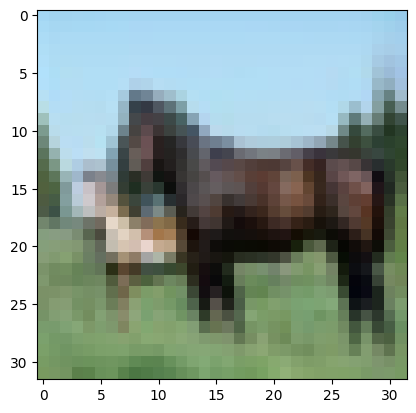

In [60]:
# Viewing the Image 12 of X_train
plt.imshow(X_train[12])

In [61]:
# Checking y_train data
y_train

array([[6],
       [9],
       [9],
       ...,
       [9],
       [1],
       [1]], dtype=uint8)

### 3. Pre-Process the Data as required

In [62]:
# Since, this is classification problem, we need to encode the y_train data
# If not the model assume the y label is a continuous data

In [63]:
# Import the library
from tensorflow.keras.utils import to_categorical

In [64]:
# Shape of the y_train
y_train.shape

(50000, 1)

#### One-hot Encoding the y

In [65]:
# Convert class labels to one-hot encoding
# num_classes=10 tells the function that your classification task has 10 different classes
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10) 

In [66]:
# the index of one represents the actual output digit
# the 8th row belongs to digit 1
y_train_cat[8]

array([0., 0., 0., 0., 0., 0., 0., 0., 1., 0.])

#### Scaling the Data

In [67]:
# Each pixel value of every image is ranging from 0 to 255
# So, normalize every value in between 0 to 1

In [68]:
# Normalize the pixel values to range [0, 1]
# the max value of any pixel is 255, so dividing each value with 255 will normalize the value to maximum 1
X_train = X_train / 255.0
X_test = X_test / 255.0

In [85]:
# Shapes of the data
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((50000, 32, 32, 3), (50000, 1), (10000, 32, 32, 3), (10000, 1))

### 4. Build the Model

In [70]:
# import the libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten

#### Create the Model

In [71]:
# Model Instance
model = Sequential()

In [72]:
# For more complex data, better to add more number of convolution & pooling layers

# Convolution Layer
model.add(Conv2D(filters=32,kernel_size=(4,4),input_shape=(32,32,3),activation='relu'))
# Pooling Layer
model.add(MaxPool2D(pool_size=(2,2)))

# Convolution Layer
model.add(Conv2D(filters=32,kernel_size=(4,4),input_shape=(32,32,3),activation='relu'))
# Pooling Layer
model.add(MaxPool2D(pool_size=(2,2)))

In [81]:
# Flatten Layer
model.add(Flatten())

In [82]:
# Dense Layers (Fully Connected Layers)
model.add(Dense(256,activation='relu'))

In [83]:
# Output Layer (For multiclass use softmax)
model.add(Dense(10,activation='softmax'))

#### Compile the Model

In [86]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [87]:
# Model Summary
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 29, 29, 32)     │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 32)     │        16,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       102,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127,188 (496.83 KB)

 Trainable params: 127,188 (496.83 KB)

 Non-trainable params: 0 (0.00 B)

### 4. Train the Model

In [88]:
# Train the model with Early Stopping
from tensorflow.keras.callbacks import EarlyStopping

In [78]:
early_stop = EarlyStopping(monitor='val_loss', patience=1)

In [89]:
# Train the model
model.fit(X_train, y_train_cat, epochs=10, validation_data=(X_test,y_test_cat), callbacks=[early_stop])

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.2410 - loss: 1.9972 - val_accuracy: 0.4626 - val_loss: 1.4542
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.4820 - loss: 1.4112 - val_accuracy: 0.5464 - val_loss: 1.2566
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.5506 - loss: 1.2390 - val_accuracy: 0.5616 - val_loss: 1.2321
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.5979 - loss: 1.1258 - val_accuracy: 0.5851 - val_loss: 1.1792
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.6292 - loss: 1.0391 - val_accuracy: 0.6220 - val_loss: 1.0831
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.6629 - loss: 0.9478 - val_accuracy: 0.6268 - val_loss: 1.0711
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.6808 - loss: 0.9028 - val_accuracy: 0.6430 - val_loss: 1.0438
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.7023 - loss: 0

### 5. Evaluate the Model

In [90]:
# Plot the accuracy because we used accuracy metric while compiling the model
metrics = pd.DataFrame(model.history.history)
metrics

,accuracy,loss,val_accuracy,val_loss
0,0.32938,1.777759,0.4626,1.454154
1,0.50380,1.363122,0.5464,1.256564
2,0.56116,1.217155,0.5616,1.232099
3,0.60248,1.116714,0.5851,1.179215
4,0.63278,1.032075,0.6220,1.083086
5,0.65792,0.964444,0.6268,1.071072
6,0.67750,0.913405,0.6430,1.043827
7,0.69872,0.861430,0.6494,1.036457
8,0.71444,0.818211,0.6460,1.045699


<Axes: >

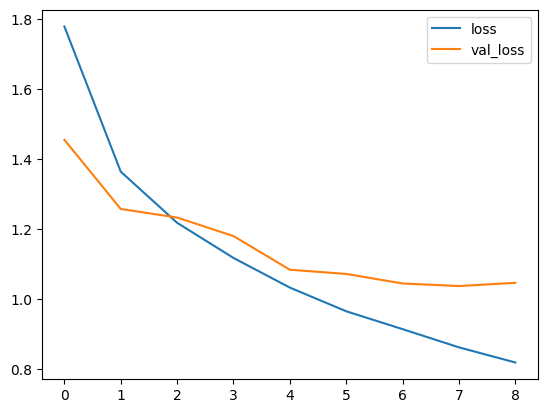

In [91]:
# Plot loss
metrics[['loss', 'val_loss']].plot()

<Axes: >

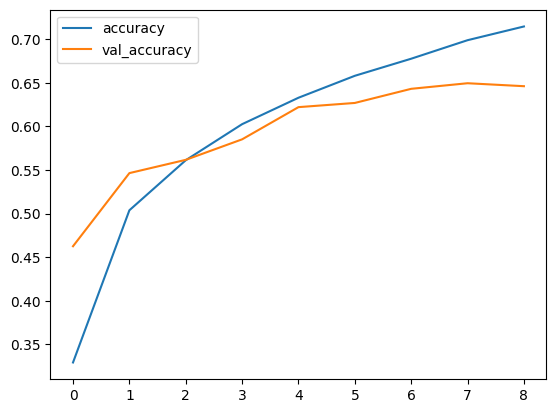

In [92]:
# Plot accuracy
metrics[['accuracy', 'val_accuracy']].plot()

#### Classification report

In [93]:
from sklearn.metrics import classification_report, confusion_matrix

In [94]:
# Get the Classifications on test data
y_pred = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step 


In [95]:
# y_test is one-hot encoded, convert it to class labels too
y_pred = np.argmax(y_pred, axis=1)

In [96]:
# Classification Report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.61      0.78      0.69      1000
           1       0.76      0.82      0.79      1000
           2       0.48      0.59      0.53      1000
           3       0.46      0.35      0.40      1000
           4       0.63      0.53      0.58      1000
           5       0.54      0.56      0.55      1000
           6       0.68      0.78      0.72      1000
           7       0.76      0.68      0.71      1000
           8       0.78      0.71      0.75      1000
           9       0.81      0.66      0.73      1000

    accuracy                           0.65     10000
   macro avg       0.65      0.65      0.64     10000
weighted avg       0.65      0.65      0.64     10000



In [97]:
# Confusion Matrix
print(confusion_matrix(y_test,y_pred))

[[780  34  57   9  14   4  10  11  60  21]
 [ 42 821  17  12   3   6  11   4  26  58]
 [ 94  13 589  58  56  68  77  20  18   7]
 [ 31  15 129 354  55 238 113  23  25  17]
 [ 43   3 159  50 527  45  78  80  12   3]
 [ 14   5 103 161  46 559  47  52   7   6]
 [  6  13  94  38  33  17 781   3   9   6]
 [ 31   3  46  37  87  91   8 675   1  21]
 [153  53  16  26   3   6  12   4 715  12]
 [ 78 123  18  26   8   9  19  18  42 659]]


#### Classiying the new image

In [106]:
from tensorflow.keras.preprocessing import image
from PIL import Image

# RGB Image
new_image = Image.open('horse.png').convert('RGB')

In [107]:
# Resize to 28x28
new_image = new_image.resize((32, 32))                  

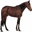

In [108]:
new_image

In [109]:
# Convert to NumPy array and normalize
img_array = np.array(new_image)
img_array = img_array / 255.0 

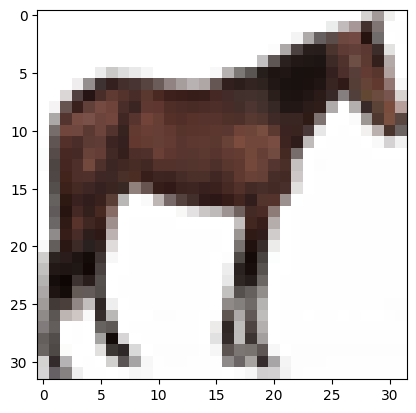

In [110]:
plt.imshow(img_array)

In [111]:
# Reshape to match input shape of model: (1, 32, 32, 3)
img_array = img_array.reshape(1, 32, 32, 3)

In [112]:
pred = model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


In [113]:
np.argmax(pred, axis=1)
# Index 7 belongs to horse

array([7])